# Insurance Claim Analysis: Advanced Statistical Modeling
**Author:** Tejaswin Amara | **University:** KLH University

## 1. Advanced Feature Engineering
Beyond simple linear effects, we investigate the **interaction effect** between Smoking and BMI, as our initial analysis suggested a compounding risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

df = pd.read_csv('../data/insurance.csv')
df = df.drop_duplicates()

# Interaction Term: BMI * Smoker
df['smoker_numeric'] = df['smoker'].map({'yes': 1, 'no': 0})
df['bmi_smoker_interaction'] = df['bmi'] * df['smoker_numeric']

print("Interaction term created: bmi_smoker_interaction")

Interaction term created: bmi_smoker_interaction


## 2. Model Implementation with Interaction
Adding interaction terms often improves model fit when features compound each other's effects.

In [2]:
X = pd.get_dummies(df[['age', 'bmi', 'children', 'smoker', 'bmi_smoker_interaction']], drop_first=True)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R2 Score (with Interaction): {r2_score(y_test, y_pred):.4f}")
joblib.dump(model, '../scripts/insurance_model.pkl')
print("Model saved to scripts/insurance_model.pkl")

R2 Score (with Interaction): 0.8834


Model saved to scripts/insurance_model.pkl


## 3. Residual Diagnostics
Validating the Gauss-Markov assumptions for Linear Regression.

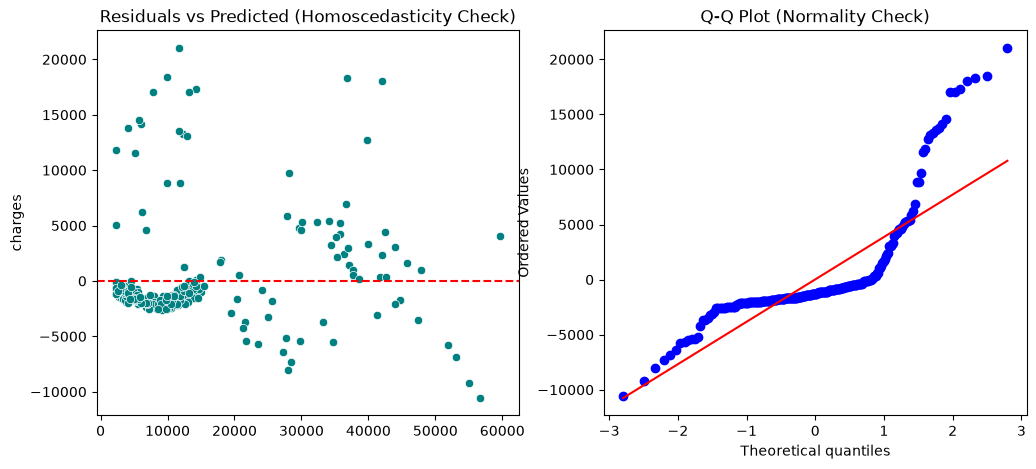

In [3]:
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted (Homoscedasticity Check)')

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Check)')
plt.show()